In [11]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver

In [12]:
load_dotenv()
model= ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.5,
)

In [13]:
class jokestate(TypedDict):
    topic : str
    joke : str
    explanation :str 

In [14]:
def generate_joke(state:jokestate):
    prompt=f"generate a joke on the topic {state['topic']}"
    response=model.invoke(prompt).content

    return {'joke':response}

In [15]:
def explain_joke(state:jokestate):
    prompt=f"explain the joke {state['joke']} for the topic {state['topic']}"
    response=model.invoke(prompt).content

    return {'explanation':response}

In [17]:
graph=StateGraph(jokestate)

graph.add_node('generate_joke',generate_joke)
graph.add_node('explain_joke',explain_joke)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','explain_joke')
graph.add_edge('explain_joke',END)

checkpointer=MemorySaver()

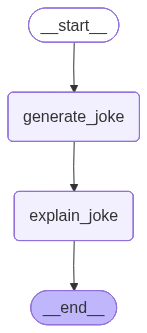

In [19]:
workflow=graph.compile(checkpointer=checkpointer)
workflow

In [20]:
config1={"configurable":{'thread_id':"1"}}
workflow.invoke({'topic':'soccer vs football'},config=config1)

{'topic': 'soccer vs football',
 'joke': 'Why did the soccer ball and the football go to therapy?\n\nBecause they had a "kick" to work out their differences, but in the end, they just couldn\'t "tackle" the fact that one of them was always getting "deflated" by the other\'s name.',
 'explanation': 'A joke that cleverly plays on the differences between soccer (or association football, as it\'s known in most of the world) and American football. Let\'s break it down:\n\n1. **"Kick" to work out their differences**: This is a pun on the phrase "kick" which has a double meaning. In both soccer and American football, kicking is a fundamental action. However, in this context, "kick" also means to start or initiate something, implying that the soccer ball and the football are trying to work through their issues.\n\n2. **"Tackle" the fact**: Another clever use of a word that has a different meaning in each sport. In American football, "tackle" refers to the act of physically bringing a player to

In [21]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'soccer vs football', 'joke': 'Why did the soccer ball and the football go to therapy?\n\nBecause they had a "kick" to work out their differences, but in the end, they just couldn\'t "tackle" the fact that one of them was always getting "deflated" by the other\'s name.', 'explanation': 'A joke that cleverly plays on the differences between soccer (or association football, as it\'s known in most of the world) and American football. Let\'s break it down:\n\n1. **"Kick" to work out their differences**: This is a pun on the phrase "kick" which has a double meaning. In both soccer and American football, kicking is a fundamental action. However, in this context, "kick" also means to start or initiate something, implying that the soccer ball and the football are trying to work through their issues.\n\n2. **"Tackle" the fact**: Another clever use of a word that has a different meaning in each sport. In American football, "tackle" refers to the act of physically b

In [23]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'soccer vs football', 'joke': 'Why did the soccer ball and the football go to therapy?\n\nBecause they had a "kick" to work out their differences, but in the end, they just couldn\'t "tackle" the fact that one of them was always getting "deflated" by the other\'s name.', 'explanation': 'A joke that cleverly plays on the differences between soccer (or association football, as it\'s known in most of the world) and American football. Let\'s break it down:\n\n1. **"Kick" to work out their differences**: This is a pun on the phrase "kick" which has a double meaning. In both soccer and American football, kicking is a fundamental action. However, in this context, "kick" also means to start or initiate something, implying that the soccer ball and the football are trying to work through their issues.\n\n2. **"Tackle" the fact**: Another clever use of a word that has a different meaning in each sport. In American football, "tackle" refers to the act of physically 

In [24]:
config2={"configurable":{'thread_id':"2"}}
workflow.invoke({'topic':'pasta'},config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.',
 'explanation': 'A delicious joke about pasta. Let\'s break it down:\n\n**The Setup:** "Why did the spaghetti refuse to get married?" This line sets up the joke by introducing the main character (spaghetti) and the situation (refusing to get married). It\'s a play on the typical joke format, where you\'d expect a person or a character to be in this situation, but instead, it\'s a type of pasta.\n\n**The Punchline:** "Because it was afraid of getting tangled up in a relationship." This is where the joke gets clever. The word "tangled" has a double meaning here:\n\n1. **Literal meaning:** Spaghetti is a long, thin, and flexible type of pasta that can easily get tangled or knotted.\n2. **Figurative meaning:** In relationships, "tangled up" is an idiomatic expression that means to become deeply involved or complicated, often in a way that\'s difficul

In [25]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'explanation': 'A delicious joke about pasta. Let\'s break it down:\n\n**The Setup:** "Why did the spaghetti refuse to get married?" This line sets up the joke by introducing the main character (spaghetti) and the situation (refusing to get married). It\'s a play on the typical joke format, where you\'d expect a person or a character to be in this situation, but instead, it\'s a type of pasta.\n\n**The Punchline:** "Because it was afraid of getting tangled up in a relationship." This is where the joke gets clever. The word "tangled" has a double meaning here:\n\n1. **Literal meaning:** Spaghetti is a long, thin, and flexible type of pasta that can easily get tangled or knotted.\n2. **Figurative meaning:** In relationships, "tangled up" is an idiomatic expression that means to become deeply involved or complicated, often in a w

In [26]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'explanation': 'A delicious joke about pasta. Let\'s break it down:\n\n**The Setup:** "Why did the spaghetti refuse to get married?" This line sets up the joke by introducing the main character (spaghetti) and the situation (refusing to get married). It\'s a play on the typical joke format, where you\'d expect a person or a character to be in this situation, but instead, it\'s a type of pasta.\n\n**The Punchline:** "Because it was afraid of getting tangled up in a relationship." This is where the joke gets clever. The word "tangled" has a double meaning here:\n\n1. **Literal meaning:** Spaghetti is a long, thin, and flexible type of pasta that can easily get tangled or knotted.\n2. **Figurative meaning:** In relationships, "tangled up" is an idiomatic expression that means to become deeply involved or complicated, often in a 